In [ ]:
!python /content/drive/MyDrive/Cluster-Aware-CLIP/extract_embeddings_clip.py --config /content/drive/MyDrive/Cluster-Aware-CLIP/config_clip.yaml


2025-12-04 21:42:20.077193: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-04 21:42:20.095725: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764884540.118367    6645 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764884540.125148    6645 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1764884540.141792    6645 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [5]:
!mkdir -p /content/coco/train2017
!mkdir -p /content/coco/annotations

# Adjust the path on the right if your structure is slightly different
!cp -r "/content/drive/MyDrive/Cluster-Aware-CLIP/data/coco/train2017" /content/coco/
!cp "/content/drive/MyDrive/Cluster-Aware-CLIP/data/coco/annotations/captions_train2017.json" /content/coco/annotations/


^C
^C


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [15]:
!python /content/drive/MyDrive/Cluster-Aware-CLIP/train_sae.py --config /content/drive/MyDrive/Cluster-Aware-CLIP/config_clip.yaml


/content/drive/MyDrive/Cluster-Aware-CLIP/train_sae.py:89: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  img_emb = torch.tensor(
[sae] Training SAE on 1183506 embeddings of dim 512
Epoch 1/20: 100% 1156/1156 [00:07<00:00, 149.41it/s]
[sae] Epoch 1/20 MSE=0.000754
Epoch 2/20: 100% 1156/1156 [00:07<00:00, 159.13it/s]
[sae] Epoch 2/20 MSE=0.000554
Epoch 3/20: 100% 1156/1156 [00:07<00:00, 156.41it/s]
[sae] Epoch 3/20 MSE=0.000520
Epoch 4/20: 100% 1156/1156 [00:07<00:00, 157.63it/s]
[sae] Epoch 4/20 MSE=0.000504
Epoch 5/20: 100% 1156/1156 [00:07<00:00, 157.91it/s]
[sae] Epoch 5/20 MSE=0.000496
Epoch 6/20: 100% 1156/1156 [00:07<00:00, 159.02it/s]
[sae] Epoch 6/20 MSE=0.000485
Epoch 7/20: 100% 1156/1156 [00:07<00:00, 154.60it/s]
[sae] Epoch 7/20 MSE=0.000473
Epoch 8/20: 100% 1

In [16]:
!python /content/drive/MyDrive/Cluster-Aware-CLIP/analyze_geometry.py --config /content/drive/MyDrive/Cluster-Aware-CLIP/config_clip.yaml


/content/drive/MyDrive/Cluster-Aware-CLIP/analyze_geometry.py:60: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  img_emb = torch.tensor(
[analysis] Embeddings img torch.Size([591753, 512]), txt torch.Size([591753, 512])
[analysis] SAE code_dim=4096, target_k=5
[analysis] Saved metrics (energy, modality, bridge) to /content/drive/MyDrive/Cluster-Aware-CLIP/clip_eval_coco/outputs


In [17]:
!python /content/drive/MyDrive/Cluster-Aware-CLIP/visualize_concepts.py --config /content/drive/MyDrive/Cluster-Aware-CLIP/config_clip.yaml --concept_id 42 --k 10


/content/drive/MyDrive/Cluster-Aware-CLIP/visualize_concepts.py:59: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  img_emb = torch.tensor(
[viz] Using concept 42 out of 4096

[Images / captions as proxy]:

=== Concept 42 top 10 examples ===
(0.0000) A assortment of food and dishes on a table.
(0.0000) A group of people sitting at a dining table.
(0.0000) A white plate of food on a dining table.
(0.0000) A open refrigerator door in a small kitchen.
(0.0000) A refeigerator door is left open to shine its light on a dark and empty kitchen
(0.0000) Plate with fries and three sandwiches topped with cherry tomatoes.
(0.0000) a refrigerator stocked full and left open with light only it's light in a dark kitchen
(0.0000) Fans pose with stuffed animals at an ice rink.
(0.0000) a p

In [18]:
import numpy as np
import matplotlib.pyplot as plt

metrics_path = "/content/clip_eval_coco/outputs/metrics/metrics.npz"
m = np.load(metrics_path)

energy = m["energy"]          # shape [m]
modality = m["modality_score"]# shape [m], in [0, 1]
B = m["bridge_matrix"]        # shape [m, m]

energy.shape, modality.shape, B.shape



((4096,), (4096,), (4096, 4096))

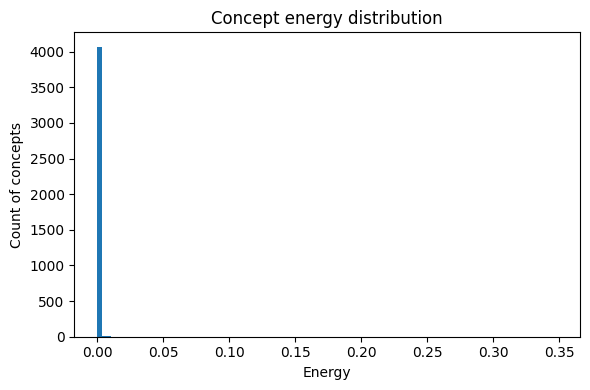

Top-10 energy concepts: [ 520 2111 3364 1066 2715  988 2699 2044 3613 3360]
Mean energy: 0.00023298606 Max: 0.34842312 Min: 0.0


In [19]:
plt.figure(figsize=(6,4))
plt.hist(energy, bins=100)
plt.xlabel("Energy")
plt.ylabel("Count of concepts")
plt.title("Concept energy distribution")
plt.tight_layout()
plt.show()

print("Top-10 energy concepts:", np.argsort(-energy)[:10])
print("Mean energy:", energy.mean(), "Max:", energy.max(), "Min:", energy.min())


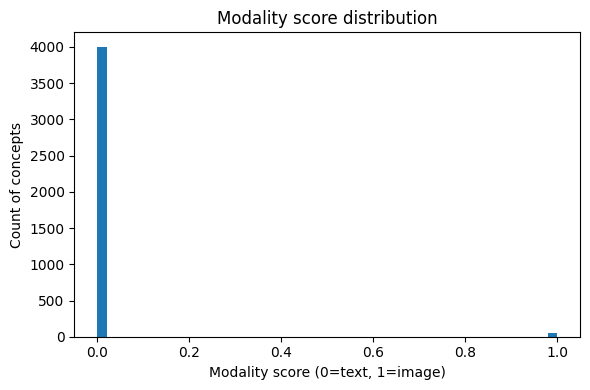

Very text-dominated concepts (modality < 0.2): 4017
Very image-dominated concepts (modality > 0.8): 58
Balanced-ish (0.4–0.6): 10


In [20]:
plt.figure(figsize=(6,4))
plt.hist(modality, bins=50, range=(0,1))
plt.xlabel("Modality score (0=text, 1=image)")
plt.ylabel("Count of concepts")
plt.title("Modality score distribution")
plt.tight_layout()
plt.show()

print("Very text-dominated concepts (modality < 0.2):", (modality < 0.2).sum())
print("Very image-dominated concepts (modality > 0.8):", (modality > 0.8).sum())
print("Balanced-ish (0.4–0.6):", ((modality > 0.4) & (modality < 0.6)).sum())


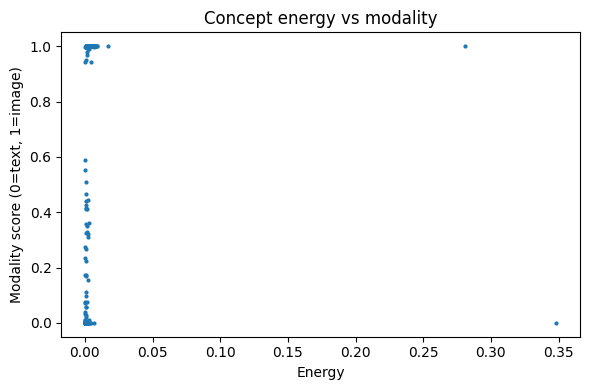

In [21]:
plt.figure(figsize=(6,4))
plt.scatter(energy, modality, s=4)
plt.xlabel("Energy")
plt.ylabel("Modality score (0=text, 1=image)")
plt.title("Concept energy vs modality")
plt.tight_layout()
plt.show()


In [22]:
import numpy as np

print("min, 50%, 90%, 99%, 99.9%, max:")
print(np.quantile(energy, [0.0, 0.5, 0.9, 0.99, 0.999, 1.0]))


min, 50%, 90%, 99%, 99.9%, max:
[0.00000000e+00 0.00000000e+00 1.00430015e-07 2.54981178e-03
 9.09530423e-03 3.48423123e-01]


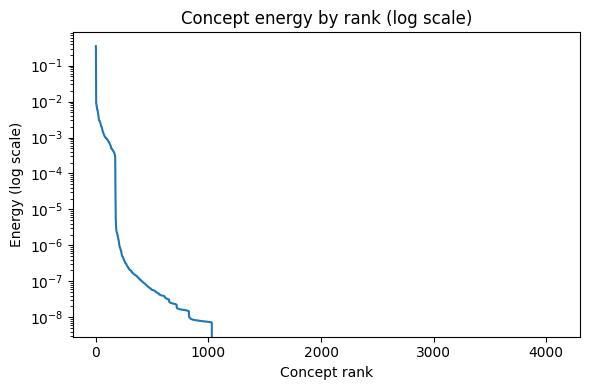

In [24]:
sorted_energy = np.sort(energy)[::-1]  # descending
plt.figure(figsize=(6,4))
plt.plot(sorted_energy)
plt.yscale("log")
plt.xlabel("Concept rank")
plt.ylabel("Energy (log scale)")
plt.title("Concept energy by rank (log scale)")
plt.tight_layout()
plt.show()



In [27]:
!python /content/drive/MyDrive/Cluster-Aware-CLIP/visualize_concepts.py --config /content/drive/MyDrive/Cluster-Aware-CLIP/config_clip.yaml --concept_id 520 --k 10
!python /content/drive/MyDrive/Cluster-Aware-CLIP/visualize_concepts.py --config /content/drive/MyDrive/Cluster-Aware-CLIP/config_clip.yaml --concept_id 2111 --k 10
!python /content/drive/MyDrive/Cluster-Aware-CLIP/visualize_concepts.py --config /content/drive/MyDrive/Cluster-Aware-CLIP/config_clip.yaml --concept_id 3364 --k 10


/content/drive/MyDrive/Cluster-Aware-CLIP/visualize_concepts.py:59: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  img_emb = torch.tensor(
[viz] Using concept 520 out of 4096

[Images / captions as proxy]:

=== Concept 520 top 10 examples ===
(0.1441) A collection of signs displayed on a public lawn.
(0.1441) a coupkle of signs on sign boards 
(0.1441) An advertisement for an upcoming program at a municipal center.
(0.1441) Signs advertising library events at the edge of a town
(0.1441) Signs posted in front of a municipal complex.
(0.1418) a photo of a person on a certificate or a label 
(0.1418) a description of a man who has passed away.
(0.1238) a woman is smiling and posing for a picture holding a frisbee
(0.1238) A girl standing in a room holding a green Frisbee.
(

In [1]:
from google.colab import files
files.download('/content/clip_eval_coco/embeddings.parquet')

FileNotFoundError: Cannot find file: /content/clip_eval_coco/embeddings.parquet